In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
pip install pydeseq2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.7 MB/s eta 0:00:00


In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [ ]:
import pandas as pd
import numpy as np
# Load the dataset. Replace 'GSE233242_Processed_file_tpm.txt' with the actual file name if different.
# Make sure the file is in the current working directory or provide the correct path.
try:
    data = pd.read_csv('GSE233242_Processed_file_tpm.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'GSE233242_Processed_file_tpm.txt' not found. Please ensure the file exists in the current directory or provide the correct path.")
except pd.errors.ParserError:
    print("Error: Could not parse the file. Please check if the file format is correct (tab-separated).")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Dataset loaded successfully.


In [ ]:
data

,gene_id,gene_name,transcriptLen,Normal_1,Tumor_1,Normal_2,Tumor_2,Normal_3,Tumor_3,Normal_4,...,Normal_39,Tumor_39,Normal_40,Tumor_40,Normal_41,Tumor_41,Normal_42,Tumor_42,Normal_43,Tumor_43
0,ENSG00000001461,NIPAL3,5481,5.9356,7.5839,8.4156,8.6940,11.9713,11.0657,7.1201,...,13.0993,7.9093,7.6512,5.3312,14.2600,11.0738,6.8080,21.0006,5.4931,18.4996
1,ENSG00000059588,TARBP1,5206,14.3604,17.0577,17.7680,44.8478,17.1972,46.3952,9.7325,...,22.7731,30.6355,9.5393,23.0233,28.3176,20.3899,10.8622,31.5134,10.6365,48.4305
2,ENSG00000049245,VAMP3,2178,114.8052,92.7879,108.7338,94.7030,86.3348,66.0318,106.9082,...,75.7453,78.6823,93.0022,75.4599,117.7420,71.5887,119.9836,75.9655,104.9702,120.7238
3,ENSG00000058799,YIPF1,1821,25.8008,58.6020,31.4842,69.4733,28.1963,57.9501,21.3538,...,68.8094,56.8996,25.9493,32.5858,62.3803,52.2184,20.5913,31.3070,22.0932,45.1147
4,ENSG00000081870,HSPB11,915,21.3901,41.4639,25.6454,38.4128,22.8817,33.8124,17.2535,...,36.2347,38.1364,19.6267,19.8945,51.9659,25.6491,17.2408,21.8410,15.2978,35.6262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15039,ENSG00000101846,STS,6622,10.2164,6.4712,4.7964,4.8476,3.4441,5.7822,11.0692,...,3.6601,3.4591,6.0753,3.6986,3.6433,3.4830,17.1431,5.2872,12.3237,5.5397
15040,ENSG00000147050,KDM6A,6135,6.7680,6.4674,11.1718,14.0186,6.7411,12.0581,7.3858,...,9.2617,11.0442,4.7588,7.2984,9.2415,6.1339,7.1009,13.5349,5.4098,13.9997
15041,ENSG00000156709,AIFM1,4157,19.0528,20.7804,12.4812,29.7255,10.6293,27.0434,17.9914,...,20.7642,25.6719,17.9800,14.0583,76.9846,18.1699,22.5504,26.7204,22.1092,31.2400
15042,ENSG00000188158,NHS,9044,1.4533,2.8162,1.4308,1.9344,1.1289,2.3032,1.2821,...,1.2136,1.6333,0.8542,1.9762,0.9281,1.0589,1.0332,0.8736,0.7885,0.3983


In [ ]:
import numpy as np

if not np.issubdtype(data.dtypes.values[0], np.integer):
    print("Non-integer values detected!")
    print(data[~data.applymap(np.isreal).all(axis=1)])

if 'gene_name' in data.columns and 'transcriptLen' in data.columns:
    data = data.drop(['gene_name', 'transcriptLen'], axis=1)
    print("Columns 'gene_name' and 'transcriptLen' dropped successfully.")
else:
    print("Error: 'gene_name' or 'transcriptLen' column not found in the DataFrame.")

data

Non-integer values detected!
               gene_id   gene_name  transcriptLen  Normal_1  Tumor_1  \
0      ENSG00000001461      NIPAL3           5481    5.9356   7.5839   
1      ENSG00000059588      TARBP1           5206   14.3604  17.0577   
2      ENSG00000049245       VAMP3           2178  114.8052  92.7879   
3      ENSG00000058799       YIPF1           1821   25.8008  58.6020   
4      ENSG00000081870      HSPB11            915   21.3901  41.4639   
...                ...         ...            ...       ...      ...   
15039  ENSG00000101846         STS           6622   10.2164   6.4712   
15040  ENSG00000147050       KDM6A           6135    6.7680   6.4674   
15041  ENSG00000156709       AIFM1           4157   19.0528  20.7804   
15042  ENSG00000188158         NHS           9044    1.4533   2.8162   
15043  ENSG00000278212  AC134878.2           1268    4.9859   7.9117   

       Normal_2  Tumor_2  Normal_3  Tumor_3  Normal_4  ...  Normal_39  \
0        8.4156   8.6940   11.971

,gene_id,Normal_1,Tumor_1,Normal_2,Tumor_2,Normal_3,Tumor_3,Normal_4,Tumor_4,Normal_5,...,Normal_39,Tumor_39,Normal_40,Tumor_40,Normal_41,Tumor_41,Normal_42,Tumor_42,Normal_43,Tumor_43
0,ENSG00000001461,5.9356,7.5839,8.4156,8.6940,11.9713,11.0657,7.1201,11.1404,8.5778,...,13.0993,7.9093,7.6512,5.3312,14.2600,11.0738,6.8080,21.0006,5.4931,18.4996
1,ENSG00000059588,14.3604,17.0577,17.7680,44.8478,17.1972,46.3952,9.7325,24.0867,15.8370,...,22.7731,30.6355,9.5393,23.0233,28.3176,20.3899,10.8622,31.5134,10.6365,48.4305
2,ENSG00000049245,114.8052,92.7879,108.7338,94.7030,86.3348,66.0318,106.9082,92.8880,106.2882,...,75.7453,78.6823,93.0022,75.4599,117.7420,71.5887,119.9836,75.9655,104.9702,120.7238
3,ENSG00000058799,25.8008,58.6020,31.4842,69.4733,28.1963,57.9501,21.3538,56.4324,26.7435,...,68.8094,56.8996,25.9493,32.5858,62.3803,52.2184,20.5913,31.3070,22.0932,45.1147
4,ENSG00000081870,21.3901,41.4639,25.6454,38.4128,22.8817,33.8124,17.2535,27.7479,23.5912,...,36.2347,38.1364,19.6267,19.8945,51.9659,25.6491,17.2408,21.8410,15.2978,35.6262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15039,ENSG00000101846,10.2164,6.4712,4.7964,4.8476,3.4441,5.7822,11.0692,3.4698,7.9506,...,3.6601,3.4591,6.0753,3.6986,3.6433,3.4830,17.1431,5.2872,12.3237,5.5397
15040,ENSG00000147050,6.7680,6.4674,11.1718,14.0186,6.7411,12.0581,7.3858,12.2561,8.8477,...,9.2617,11.0442,4.7588,7.2984,9.2415,6.1339,7.1009,13.5349,5.4098,13.9997
15041,ENSG00000156709,19.0528,20.7804,12.4812,29.7255,10.6293,27.0434,17.9914,17.4523,12.7917,...,20.7642,25.6719,17.9800,14.0583,76.9846,18.1699,22.5504,26.7204,22.1092,31.2400
15042,ENSG00000188158,1.4533,2.8162,1.4308,1.9344,1.1289,2.3032,1.2821,2.3754,1.6358,...,1.2136,1.6333,0.8542,1.9762,0.9281,1.0589,1.0332,0.8736,0.7885,0.3983


In [ ]:
# Separate Gene column
gene_column = data['gene_id']
numeric_data = data.drop(columns=['gene_id'])

# Process numeric data
numeric_data = numeric_data.round().astype(int)

# Recombine
data = pd.concat([gene_column, numeric_data], axis=1)
data


,gene_id,Normal_1,Tumor_1,Normal_2,Tumor_2,Normal_3,Tumor_3,Normal_4,Tumor_4,Normal_5,...,Normal_39,Tumor_39,Normal_40,Tumor_40,Normal_41,Tumor_41,Normal_42,Tumor_42,Normal_43,Tumor_43
0,ENSG00000001461,6,8,8,9,12,11,7,11,9,...,13,8,8,5,14,11,7,21,5,18
1,ENSG00000059588,14,17,18,45,17,46,10,24,16,...,23,31,10,23,28,20,11,32,11,48
2,ENSG00000049245,115,93,109,95,86,66,107,93,106,...,76,79,93,75,118,72,120,76,105,121
3,ENSG00000058799,26,59,31,69,28,58,21,56,27,...,69,57,26,33,62,52,21,31,22,45
4,ENSG00000081870,21,41,26,38,23,34,17,28,24,...,36,38,20,20,52,26,17,22,15,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15039,ENSG00000101846,10,6,5,5,3,6,11,3,8,...,4,3,6,4,4,3,17,5,12,6
15040,ENSG00000147050,7,6,11,14,7,12,7,12,9,...,9,11,5,7,9,6,7,14,5,14
15041,ENSG00000156709,19,21,12,30,11,27,18,17,13,...,21,26,18,14,77,18,23,27,22,31
15042,ENSG00000188158,1,3,1,2,1,2,1,2,2,...,1,2,1,2,1,1,1,1,1,0


,gene_id,Normal_1,Normal_10,Normal_11,Normal_12,Normal_13,Normal_14,Normal_15,Normal_16,Normal_17,...,Tumor_4,Tumor_40,Tumor_41,Tumor_42,Tumor_43,Tumor_5,Tumor_6,Tumor_7,Tumor_8,Tumor_9
0,ENSG00000001461,6,8,4,5,7,5,10,10,5,...,11,5,11,21,18,9,6,15,11,4
1,ENSG00000059588,14,21,12,6,17,10,15,18,11,...,24,23,20,32,48,25,57,53,49,26
2,ENSG00000049245,115,79,129,107,108,135,88,84,121,...,93,75,72,76,121,78,66,78,80,61
3,ENSG00000058799,26,29,19,20,20,23,54,33,20,...,56,33,52,31,45,33,23,45,52,24
4,ENSG00000081870,21,26,20,14,20,19,26,27,15,...,28,20,26,22,36,28,17,31,28,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15039,ENSG00000101846,10,4,9,12,14,18,6,3,13,...,3,4,3,5,6,7,2,5,2,4
15040,ENSG00000147050,7,9,7,5,9,7,7,10,5,...,12,7,6,14,14,11,6,11,12,8
15041,ENSG00000156709,19,14,20,18,27,21,17,15,23,...,17,14,18,27,31,26,16,15,23,41
15042,ENSG00000188158,1,2,1,1,1,1,1,2,1,...,2,2,1,1,0,1,1,2,2,1


In [ ]:
import pandas as pd

# Example DataFrame
columns = ['gene_id'] + [f"Normal_{i}" for i in range(1, 44)] + [f"Tumor_{i}" for i in range(1, 44)]
df = pd.DataFrame(columns=columns)

# Rearrange columns
normal_columns = [f"Normal_{i}" for i in range(1, 44)]
tumor_columns = [f"Tumor_{i}" for i in range(1, 44)]
new_order = ['gene_id'] + normal_columns + tumor_columns

# Apply new column order
df = data[new_order]

print(df.columns)


Index(['gene_id', 'Normal_1', 'Normal_2', 'Normal_3', 'Normal_4', 'Normal_5',
       'Normal_6', 'Normal_7', 'Normal_8', 'Normal_9', 'Normal_10',
       'Normal_11', 'Normal_12', 'Normal_13', 'Normal_14', 'Normal_15',
       'Normal_16', 'Normal_17', 'Normal_18', 'Normal_19', 'Normal_20',
       'Normal_21', 'Normal_22', 'Normal_23', 'Normal_24', 'Normal_25',
       'Normal_26', 'Normal_27', 'Normal_28', 'Normal_29', 'Normal_30',
       'Normal_31', 'Normal_32', 'Normal_33', 'Normal_34', 'Normal_35',
       'Normal_36', 'Normal_37', 'Normal_38', 'Normal_39', 'Normal_40',
       'Normal_41', 'Normal_42', 'Normal_43', 'Tumor_1', 'Tumor_2', 'Tumor_3',
       'Tumor_4', 'Tumor_5', 'Tumor_6', 'Tumor_7', 'Tumor_8', 'Tumor_9',
       'Tumor_10', 'Tumor_11', 'Tumor_12', 'Tumor_13', 'Tumor_14', 'Tumor_15',
       'Tumor_16', 'Tumor_17', 'Tumor_18', 'Tumor_19', 'Tumor_20', 'Tumor_21',
       'Tumor_22', 'Tumor_23', 'Tumor_24', 'Tumor_25', 'Tumor_26', 'Tumor_27',
       'Tumor_28', 'Tumor_29', 'T

In [ ]:
data=df
df

,gene_id,Normal_1,Normal_2,Normal_3,Normal_4,Normal_5,Normal_6,Normal_7,Normal_8,Normal_9,...,Tumor_34,Tumor_35,Tumor_36,Tumor_37,Tumor_38,Tumor_39,Tumor_40,Tumor_41,Tumor_42,Tumor_43
0,ENSG00000001461,6,8,12,7,9,9,7,11,8,...,16,8,8,7,14,8,5,11,21,18
1,ENSG00000059588,14,18,17,10,16,12,16,26,16,...,41,25,39,22,42,31,23,20,32,48
2,ENSG00000049245,115,109,86,107,106,88,101,89,81,...,56,87,53,70,87,79,75,72,76,121
3,ENSG00000058799,26,31,28,21,27,35,34,59,52,...,80,26,81,26,48,57,33,52,31,45
4,ENSG00000081870,21,26,23,17,24,23,23,33,28,...,51,23,45,17,41,38,20,26,22,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15039,ENSG00000101846,10,5,3,11,8,3,5,6,3,...,9,4,2,4,5,3,4,3,5,6
15040,ENSG00000147050,7,11,7,7,9,5,8,10,7,...,8,9,10,6,11,11,7,6,14,14
15041,ENSG00000156709,19,12,11,18,13,13,15,20,15,...,34,31,20,15,26,26,14,18,27,31
15042,ENSG00000188158,1,1,1,1,2,1,1,1,1,...,0,2,1,1,1,2,2,1,1,0


In [ ]:
# Check if any zero values exist
has_zeros = (data == 0).any().any()
print(f"Are there any zeros in the DataFrame? {has_zeros}")

# Count total zero values in the entire DataFrame
total_zeros = (data == 0).sum().sum()
print(f"Total number of zeros: {total_zeros}")

# Check which columns contain zeros
columns_with_zeros = data.columns[(data == 0).any()]
print(f"Columns with zero values: {columns_with_zeros.tolist()}")


Are there any zeros in the DataFrame? True
Total number of zeros: 35048
Columns with zero values: ['Normal_1', 'Normal_2', 'Normal_3', 'Normal_4', 'Normal_5', 'Normal_6', 'Normal_7', 'Normal_8', 'Normal_9', 'Normal_10', 'Normal_11', 'Normal_12', 'Normal_13', 'Normal_14', 'Normal_15', 'Normal_16', 'Normal_17', 'Normal_18', 'Normal_19', 'Normal_20', 'Normal_21', 'Normal_22', 'Normal_23', 'Normal_24', 'Normal_25', 'Normal_26', 'Normal_27', 'Normal_28', 'Normal_29', 'Normal_30', 'Normal_31', 'Normal_32', 'Normal_33', 'Normal_34', 'Normal_35', 'Normal_36', 'Normal_37', 'Normal_38', 'Normal_39', 'Normal_40', 'Normal_41', 'Normal_42', 'Normal_43', 'Tumor_1', 'Tumor_2', 'Tumor_3', 'Tumor_4', 'Tumor_5', 'Tumor_6', 'Tumor_7', 'Tumor_8', 'Tumor_9', 'Tumor_10', 'Tumor_11', 'Tumor_12', 'Tumor_13', 'Tumor_14', 'Tumor_15', 'Tumor_16', 'Tumor_17', 'Tumor_18', 'Tumor_19', 'Tumor_20', 'Tumor_21', 'Tumor_22', 'Tumor_23', 'Tumor_24', 'Tumor_25', 'Tumor_26', 'Tumor_27', 'Tumor_28', 'Tumor_29', 'Tumor_30', 

In [ ]:
# Get rows where any column has a zero
rows_with_zeros = data[(data == 0).any(axis=1)]
print("Rows with zero values:")
print(rows_with_zeros)


Rows with zero values:
               gene_id  Normal_1  Normal_2  Normal_3  Normal_4  Normal_5  \
7      ENSG00000094963        17        39        19        53        80   
10     ENSG00000116194        34        21        19        22        15   
17     ENSG00000116704         3         3         3         2         4   
25     ENSG00000120332        13         7         5        13        14   
32     ENSG00000117245         3         2         2         2         3   
...                ...       ...       ...       ...       ...       ...   
15034  ENSG00000267064         0         0         0         0         1   
15035  ENSG00000224281         2         2         1         1         1   
15038  ENSG00000008086         1         1         1         1         2   
15042  ENSG00000188158         1         1         1         1         2   
15043  ENSG00000278212         5         1         4         3         5   

       Normal_6  Normal_7  Normal_8  Normal_9  ...  Tumor_34  Tu

In [ ]:
# Replace zeros with the mean of each column
data = data.apply(lambda col: col.replace(0, col[col != 0].mean()) if col.dtype in ['float64', 'int64'] else col)


In [ ]:
print(f"Any zeros remaining? {(data == 0).any().any()}")

# Separate Gene column
gene_column = data['gene_id']
numeric_data = data.drop(columns=['gene_id'])

# Process numeric data
numeric_data = numeric_data.round().astype(int)

# Recombine
data = pd.concat([gene_column, numeric_data], axis=1)
data


Any zeros remaining? False


,gene_id,Normal_1,Normal_2,Normal_3,Normal_4,Normal_5,Normal_6,Normal_7,Normal_8,Normal_9,...,Tumor_34,Tumor_35,Tumor_36,Tumor_37,Tumor_38,Tumor_39,Tumor_40,Tumor_41,Tumor_42,Tumor_43
0,ENSG00000001461,6,8,12,7,9,9,7,11,8,...,16,8,8,7,14,8,5,11,21,18
1,ENSG00000059588,14,18,17,10,16,12,16,26,16,...,41,25,39,22,42,31,23,20,32,48
2,ENSG00000049245,115,109,86,107,106,88,101,89,81,...,56,87,53,70,87,79,75,72,76,121
3,ENSG00000058799,26,31,28,21,27,35,34,59,52,...,80,26,81,26,48,57,33,52,31,45
4,ENSG00000081870,21,26,23,17,24,23,23,33,28,...,51,23,45,17,41,38,20,26,22,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15039,ENSG00000101846,10,5,3,11,8,3,5,6,3,...,9,4,2,4,5,3,4,3,5,6
15040,ENSG00000147050,7,11,7,7,9,5,8,10,7,...,8,9,10,6,11,11,7,6,14,14
15041,ENSG00000156709,19,12,11,18,13,13,15,20,15,...,34,31,20,15,26,26,14,18,27,31
15042,ENSG00000188158,1,1,1,1,2,1,1,1,1,...,70,2,1,1,1,2,2,1,1,70


In [ ]:
counts=data.set_index('gene_id')
counts

,Normal_1,Normal_2,Normal_3,Normal_4,Normal_5,Normal_6,Normal_7,Normal_8,Normal_9,Normal_10,...,Tumor_34,Tumor_35,Tumor_36,Tumor_37,Tumor_38,Tumor_39,Tumor_40,Tumor_41,Tumor_42,Tumor_43
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000001461,6,8,12,7,9,9,7,11,8,8,...,16,8,8,7,14,8,5,11,21,18
ENSG00000059588,14,18,17,10,16,12,16,26,16,21,...,41,25,39,22,42,31,23,20,32,48
ENSG00000049245,115,109,86,107,106,88,101,89,81,79,...,56,87,53,70,87,79,75,72,76,121
ENSG00000058799,26,31,28,21,27,35,34,59,52,29,...,80,26,81,26,48,57,33,52,31,45
ENSG00000081870,21,26,23,17,24,23,23,33,28,26,...,51,23,45,17,41,38,20,26,22,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000101846,10,5,3,11,8,3,5,6,3,4,...,9,4,2,4,5,3,4,3,5,6
ENSG00000147050,7,11,7,7,9,5,8,10,7,9,...,8,9,10,6,11,11,7,6,14,14
ENSG00000156709,19,12,11,18,13,13,15,20,15,14,...,34,31,20,15,26,26,14,18,27,31


In [ ]:
counts=counts[counts.sum(axis = 1)>0]
counts

,Normal_1,Normal_2,Normal_3,Normal_4,Normal_5,Normal_6,Normal_7,Normal_8,Normal_9,Normal_10,...,Tumor_34,Tumor_35,Tumor_36,Tumor_37,Tumor_38,Tumor_39,Tumor_40,Tumor_41,Tumor_42,Tumor_43
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000001461,6,8,12,7,9,9,7,11,8,8,...,16,8,8,7,14,8,5,11,21,18
ENSG00000059588,14,18,17,10,16,12,16,26,16,21,...,41,25,39,22,42,31,23,20,32,48
ENSG00000049245,115,109,86,107,106,88,101,89,81,79,...,56,87,53,70,87,79,75,72,76,121
ENSG00000058799,26,31,28,21,27,35,34,59,52,29,...,80,26,81,26,48,57,33,52,31,45
ENSG00000081870,21,26,23,17,24,23,23,33,28,26,...,51,23,45,17,41,38,20,26,22,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000101846,10,5,3,11,8,3,5,6,3,4,...,9,4,2,4,5,3,4,3,5,6
ENSG00000147050,7,11,7,7,9,5,8,10,7,9,...,8,9,10,6,11,11,7,6,14,14
ENSG00000156709,19,12,11,18,13,13,15,20,15,14,...,34,31,20,15,26,26,14,18,27,31


In [ ]:
counts=counts.T
counts

gene_id,ENSG00000001461,ENSG00000059588,ENSG00000049245,ENSG00000058799,ENSG00000081870,ENSG00000083444,ENSG00000076321,ENSG00000094963,ENSG00000031698,ENSG00000116128,...,ENSG00000267064,ENSG00000224281,ENSG00000236120,ENSG00000235437,ENSG00000008086,ENSG00000101846,ENSG00000147050,ENSG00000156709,ENSG00000188158,ENSG00000278212
Normal_1,6,14,115,26,21,104,11,17,132,7,...,68,2,4,15,1,10,7,19,1,5
Normal_2,8,18,109,31,26,95,8,39,132,7,...,68,2,1,15,1,5,11,12,1,1
Normal_3,12,17,86,28,23,62,6,19,135,5,...,68,1,4,17,1,3,7,11,1,4
Normal_4,7,10,107,21,17,67,10,53,120,6,...,68,1,2,11,1,11,7,18,1,3
Normal_5,9,16,106,27,24,81,10,80,125,7,...,1,1,5,14,2,8,9,13,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tumor_39,8,31,79,57,38,101,10,2,132,23,...,1,2,4,21,1,3,11,26,2,1
Tumor_40,5,23,75,33,20,128,9,11,111,13,...,67,1,6,14,2,4,7,14,2,1
Tumor_41,11,20,72,52,26,68,5,22,153,10,...,1,2,1,20,1,3,6,18,1,6
Tumor_42,21,32,76,31,22,95,10,2,136,16,...,1,2,2,4,2,5,14,27,1,1


In [ ]:
metadata = pd.DataFrame(
    zip(
        counts.index,
        ['N', 'N', 'N', 'N', 'N', 'N',
         'N', 'N', 'N', 'N', 'N', 'N',
         'N', 'N', 'N', 'N', 'N', 'N',
         'N', 'N', 'N', 'N', 'N', 'N',
         'N', 'N', 'N', 'N', 'N', 'N',
         'N', 'N', 'N', 'N', 'N', 'N',
         'N', 'N', 'N', 'N', 'N', 'N',
         'N', 'T', 'T', 'T', 'T', 'T',
         'T', 'T', 'T', 'T', 'T', 'T',
         'T', 'T', 'T', 'T', 'T', 'T',
         'T', 'T', 'T', 'T', 'T', 'T',
         'T', 'T', 'T', 'T', 'T', 'T',
         'T', 'T', 'T', 'T', 'T', 'T',
         'T', 'T', 'T', 'T', 'T', 'T',
         'T','T',]),
    columns=['Sample','Condition']
)


In [ ]:
metadata = metadata.set_index('Sample')
metadata

,Condition
Sample,
Normal_1,N
Normal_2,N
Normal_3,N
Normal_4,N
Normal_5,N
...,...
Tumor_39,T
Tumor_40,T
Tumor_41,T


In [ ]:
dds = DeseqDataSet(counts=counts,
             metadata=metadata,
             design_factors='Condition')


In [ ]:
dds.var

""
gene_id
ENSG00000001461
ENSG00000059588
ENSG00000049245
ENSG00000058799
ENSG00000081870
...
ENSG00000101846
ENSG00000147050
ENSG00000156709


In [ ]:
dds.deseq2()

Fitting size factors...
... done in 0.13 seconds.

Fitting dispersions...
... done in 27.17 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.10/dist-packages/pydeseq2/dds.py:727: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.41 seconds.

Fitting MAP dispersions...
... done in 45.98 seconds.

Fitting LFCs...
... done in 14.80 seconds.

Calculating cook's distance...
... done in 0.17 seconds.

Replacing 1332 outlier genes.

Fitting dispersions...
... done in 1.91 seconds.

Fitting MAP dispersions...
... done in 5.35 seconds.

Fitting LFCs...
... done in 1.14 seconds.



In [ ]:
dds

AnnData object with n_obs × n_vars = 86 × 15044
    obs: 'Condition'
    uns: 'mean_disp', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable'
    varm: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks'

In [ ]:
stat_res = DeseqStats(dds,contrast=('Condition','N','T'))

In [ ]:
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Condition N vs T
                  baseMean  log2FoldChange     lfcSE      stat        pvalue  \
gene_id                                                                        
ENSG00000001461   8.317240       -0.046359  0.120494 -0.384740  7.004301e-01   
ENSG00000059588  20.821002       -0.703796  0.127238 -5.531350  3.177754e-08   
ENSG00000049245  92.363626        0.652114  0.077931  8.367861  5.867364e-17   
ENSG00000058799  39.074639       -0.454633  0.106325 -4.275897  1.903694e-05   
ENSG00000081870  29.132877       -0.270078  0.103586 -2.607285  9.126327e-03   
...                    ...             ...       ...       ...           ...   
ENSG00000101846   7.732336        0.805494  0.213999  3.764013  1.672083e-04   
ENSG00000147050   8.290497       -0.233230  0.111788 -2.086353  3.694664e-02   
ENSG00000156709  20.997291       -0.123777  0.108044 -1.145618  2.519534e-01   
ENSG00000188158   6.371625        0.384253  0.474941  0.809054  4

... done in 4.02 seconds.



In [ ]:
res = stat_res.results_df
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000001461,8.317240,-0.046359,0.120494,-0.384740,7.004301e-01,7.629069e-01
ENSG00000059588,20.821002,-0.703796,0.127238,-5.531350,3.177754e-08,2.579932e-07
ENSG00000049245,92.363626,0.652114,0.077931,8.367861,5.867364e-17,3.356222e-15
ENSG00000058799,39.074639,-0.454633,0.106325,-4.275897,1.903694e-05,7.966391e-05
ENSG00000081870,29.132877,-0.270078,0.103586,-2.607285,9.126327e-03,1.874423e-02
...,...,...,...,...,...,...
ENSG00000101846,7.732336,0.805494,0.213999,3.764013,1.672083e-04,5.494718e-04
ENSG00000147050,8.290497,-0.233230,0.111788,-2.086353,3.694664e-02,6.362468e-02
ENSG00000156709,20.997291,-0.123777,0.108044,-1.145618,2.519534e-01,3.308647e-01


In [ ]:
pip install sanbomics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.8 MB/s eta 0:00:00


In [ ]:
from sanbomics.tools import id_map

mapper = id_map(species='human')
mapper.mapper

{'ENSG00000210049': 'MT-TF',
 'ENSG00000211459': 'MT-RNR1',
 'ENSG00000210077': 'MT-TV',
 'ENSG00000210082': 'MT-RNR2',
 'ENSG00000209082': 'MT-TL1',
 'ENSG00000198888': 'MT-ND1',
 'ENSG00000210100': 'MT-TI',
 'ENSG00000210107': 'MT-TQ',
 'ENSG00000210112': 'MT-TM',
 'ENSG00000198763': 'MT-ND2',
 'ENSG00000210117': 'MT-TW',
 'ENSG00000210127': 'MT-TA',
 'ENSG00000210135': 'MT-TN',
 'ENSG00000210140': 'MT-TC',
 'ENSG00000210144': 'MT-TY',
 'ENSG00000198804': 'MT-CO1',
 'ENSG00000210151': 'MT-TS1',
 'ENSG00000210154': 'MT-TD',
 'ENSG00000198712': 'MT-CO2',
 'ENSG00000210156': 'MT-TK',
 'ENSG00000228253': 'MT-ATP8',
 'ENSG00000198899': 'MT-ATP6',
 'ENSG00000198938': 'MT-CO3',
 'ENSG00000210164': 'MT-TG',
 'ENSG00000198840': 'MT-ND3',
 'ENSG00000210174': 'MT-TR',
 'ENSG00000212907': 'MT-ND4L',
 'ENSG00000198886': 'MT-ND4',
 'ENSG00000210176': 'MT-TH',
 'ENSG00000210184': 'MT-TS2',
 'ENSG00000210191': 'MT-TL2',
 'ENSG00000198786': 'MT-ND5',
 'ENSG00000198695': 'MT-ND6',
 'ENSG00000210194': 

In [ ]:
res['Symbol'] = res.index.map(mapper.mapper)
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000001461,8.317240,-0.046359,0.120494,-0.384740,7.004301e-01,7.629069e-01,NIPAL3
ENSG00000059588,20.821002,-0.703796,0.127238,-5.531350,3.177754e-08,2.579932e-07,TARBP1
ENSG00000049245,92.363626,0.652114,0.077931,8.367861,5.867364e-17,3.356222e-15,VAMP3
ENSG00000058799,39.074639,-0.454633,0.106325,-4.275897,1.903694e-05,7.966391e-05,YIPF1
ENSG00000081870,29.132877,-0.270078,0.103586,-2.607285,9.126327e-03,1.874423e-02,HSPB11
...,...,...,...,...,...,...,...
ENSG00000101846,7.732336,0.805494,0.213999,3.764013,1.672083e-04,5.494718e-04,STS
ENSG00000147050,8.290497,-0.233230,0.111788,-2.086353,3.694664e-02,6.362468e-02,KDM6A
ENSG00000156709,20.997291,-0.123777,0.108044,-1.145618,2.519534e-01,3.308647e-01,AIFM1


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
res = res[res.baseMean >= 8]
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000001461,8.317240,-0.046359,0.120494,-0.384740,7.004301e-01,7.629069e-01,NIPAL3
ENSG00000059588,20.821002,-0.703796,0.127238,-5.531350,3.177754e-08,2.579932e-07,TARBP1
ENSG00000049245,92.363626,0.652114,0.077931,8.367861,5.867364e-17,3.356222e-15,VAMP3
ENSG00000058799,39.074639,-0.454633,0.106325,-4.275897,1.903694e-05,7.966391e-05,YIPF1
ENSG00000081870,29.132877,-0.270078,0.103586,-2.607285,9.126327e-03,1.874423e-02,HSPB11
...,...,...,...,...,...,...,...
ENSG00000223546,25.870591,1.214182,0.530429,2.289058,2.207599e-02,4.055577e-02,LINC00630
ENSG00000267064,43.701039,0.955599,0.449748,2.124741,3.360819e-02,5.851871e-02,UXT-AS1
ENSG00000235437,18.248603,-0.050536,0.131797,-0.383437,7.013957e-01,7.637375e-01,LINC01278


In [ ]:
sigs = res[(res.padj < 0.05) & (abs(res.log2FoldChange)>0.5)]
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000059588,20.821002,-0.703796,0.127238,-5.531350,3.177754e-08,2.579932e-07,TARBP1
ENSG00000049245,92.363626,0.652114,0.077931,8.367861,5.867364e-17,3.356222e-15,VAMP3
ENSG00000094963,22.745247,1.703675,0.256408,6.644384,3.044883e-11,5.095353e-10,FMO2
ENSG00000116128,11.511589,-1.149214,0.155788,-7.376757,1.621918e-13,4.357166e-12,BCL9
ENSG00000116741,122.876750,0.859270,0.200409,4.287581,1.806294e-05,7.620270e-05,RGS2
...,...,...,...,...,...,...,...
ENSG00000279245,9.220747,-1.100489,0.490418,-2.243982,2.483354e-02,4.500612e-02,FAM223A
ENSG00000281852,21.951429,-1.340155,0.488772,-2.741881,6.108853e-03,1.320805e-02,LINC00891
ENSG00000260081,10.243679,-1.204547,0.505824,-2.381359,1.724889e-02,3.276832e-02,MRFAP1P1


In [ ]:
pip install scanpy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.6/83.6 kB 4.6 MB/s eta 0:00:00
  Created wheel for session-info: filename=session_info-1.0.0-py3-none-any.whl size=8023 sha256=866ffedcbf582d942bcc7c426bf364656e7f6baf126b3b160f6f1d0a8a59cf21
  Stored in directory: /root/.cache/pip/wheels/6a/aa/b9/eb5d4031476ec10802795b97ccf937b9bd998d68a9b268765a
Successfully built session-info


In [ ]:
import scanpy as sc
dds

AnnData object with n_obs × n_vars = 86 × 15044
    obs: 'Condition'
    uns: 'mean_disp', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable'
    varm: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks'

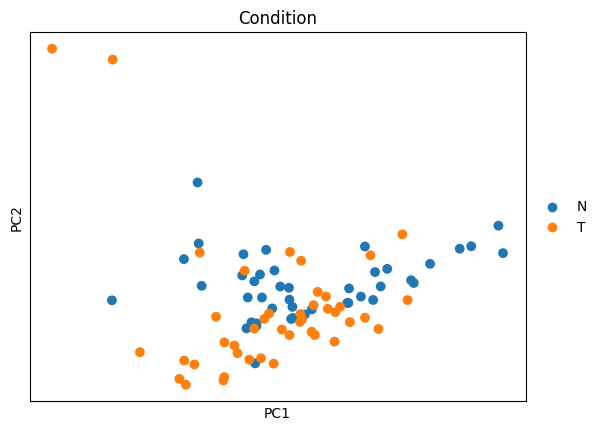

In [ ]:
sc.tl.pca(dds)
sc.pl.pca(dds,color = 'Condition', size=200)

In [ ]:
pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.5/548.5 kB 8.0 MB/s eta 0:00:00


In [ ]:
import gseapy as gp
from gseapy.plot import gseaplot

rank = res[['Symbol','stat']].dropna().sort_values(by='stat',ascending=False)
rank

,Symbol,stat
gene_id,,
ENSG00000186994,KANK3,12.376656
ENSG00000148180,GSN,11.782412
ENSG00000165804,ZNF219,11.529610
ENSG00000188536,HBA2,11.475372
ENSG00000079308,TNS1,11.403177
...,...,...
ENSG00000133466,C1QTNF6,-10.355326
ENSG00000115414,FN1,-10.428995
ENSG00000133110,POSTN,-10.470301


In [ ]:
rank = rank.drop_duplicates(subset=['Symbol'])
rank

,Symbol,stat
gene_id,,
ENSG00000186994,KANK3,12.376656
ENSG00000148180,GSN,11.782412
ENSG00000165804,ZNF219,11.529610
ENSG00000188536,HBA2,11.475372
ENSG00000079308,TNS1,11.403177
...,...,...
ENSG00000133466,C1QTNF6,-10.355326
ENSG00000115414,FN1,-10.428995
ENSG00000133110,POSTN,-10.470301


In [ ]:
gp.get_library_name()

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMap_CRISPR_GeneDependency_CellLines_2023',
 'DepMap_WG_CRISPR_Screens_Broad_CellLines_2019',
 'DepMap_WG_CRISPR_Screens_Sanger_Cell

In [ ]:
manual_set = {'things':['KANK3','GSN','ZNF219','HBA2','TNS1']}

In [ ]:
print(rank.head())  # Should have two columns
print(rank.columns)  # Should list ['gene', 'score'] or similar


                 Symbol       stat
gene_id                           
ENSG00000186994   KANK3  12.376656
ENSG00000148180     GSN  11.782412
ENSG00000165804  ZNF219  11.529610
ENSG00000188536    HBA2  11.475372
ENSG00000079308    TNS1  11.403177
Index(['Symbol', 'stat'], dtype='object')


In [ ]:
print(len(manual_set["things"]))
print(rank["Symbol"].head())


5
gene_id
ENSG00000186994     KANK3
ENSG00000148180       GSN
ENSG00000165804    ZNF219
ENSG00000188536      HBA2
ENSG00000079308      TNS1
Name: Symbol, dtype: object


In [ ]:
rank = rank.reset_index()  # Move 'gene_id' from index to a column
rank = rank.rename(columns={"Symbol": "gene", "stat": "score"})

In [ ]:
custom_genes = set(manual_set["things"])  # Genes in your custom set
ranked_genes1 = set(rank["gene"])  # Genes in the rank1 dataframe
overlap = custom_genes & ranked_genes1
print(f"Number of overlapping genes: {len(overlap)}")
if len(overlap) == 0:
    print("No overlapping genes between rank1 and manual_set.")

Number of overlapping genes: 5


In [ ]:
rank

,gene_id,gene,score
0,ENSG00000186994,KANK3,12.376656
1,ENSG00000148180,GSN,11.782412
2,ENSG00000165804,ZNF219,11.529610
3,ENSG00000188536,HBA2,11.475372
4,ENSG00000079308,TNS1,11.403177
...,...,...,...
10866,ENSG00000133466,C1QTNF6,-10.355326
10867,ENSG00000115414,FN1,-10.428995
10868,ENSG00000133110,POSTN,-10.470301
10869,ENSG00000059573,ALDH18A1,-11.042251


In [ ]:
rank = rank.drop(columns=['gene_id'])

In [ ]:
pre_res1 = gp.prerank(rnk=rank,
                     gene_sets=['GO_Biological_Process_2021',manual_set],
                     seed=6 ,permutation_num=100)

2024-11-24 15:34:18,231 [WARNING] Duplicated values found in preranked stats: 0.06% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [ ]:
out1 = []


for term in list(pre_res1.results):
    out1.append([term,
               pre_res1.results[term]['fdr'],
               pre_res1.results[term]['es'],
               pre_res1.results[term]['nes']])

out_df1 = pd.DataFrame(out1, columns = ['Term','fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)

In [ ]:
out_df1

,Term,fdr,es,nes
0,GO_Biological_Process_2021__protein targeting ...,0.000000,0.527582,2.356518
1,GO_Biological_Process_2021__positive regulatio...,0.000000,0.764312,2.297276
2,GO_Biological_Process_2021__cytoplasmic transl...,0.000000,0.617792,2.692645
3,GO_Biological_Process_2021__cotranslational pr...,0.000000,0.548411,2.415314
4,GO_Biological_Process_2021__negative regulatio...,0.000000,0.661770,2.280081
...,...,...,...,...
2049,GO_Biological_Process_2021__response to interf...,0.996385,0.160843,0.521476
2050,GO_Biological_Process_2021__epidermal growth f...,0.996943,-0.143507,-0.491112
2051,GO_Biological_Process_2021__regulation of exos...,0.997721,0.160994,0.495534
2052,GO_Biological_Process_2021__non-motile cilium ...,0.998612,0.141876,0.449620


In [ ]:
out_df1.sort_values('nes').iloc[0].Term

'GO_Biological_Process_2021__protein N-linked glycosylation (GO:0006487)'

[<Axes: xlabel='Gene Rank'>, <Axes: ylabel='Enrichment Score'>]

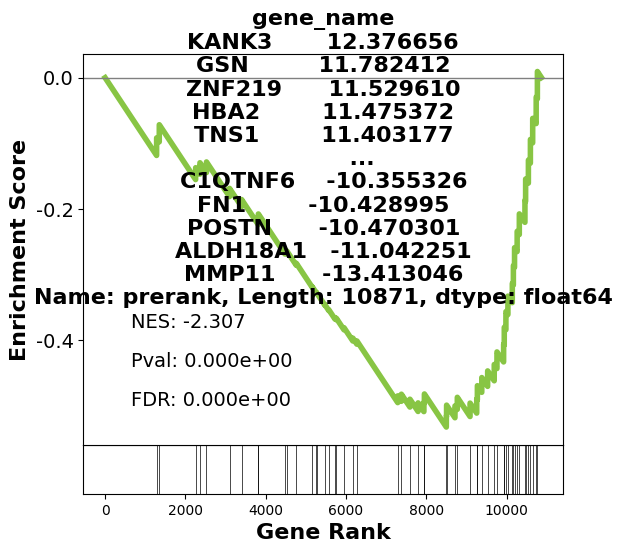

In [ ]:
gseaplot(pre_res1.ranking,
         **pre_res1.results['GO_Biological_Process_2021__protein N-linked glycosylation (GO:0006487)'])


In [ ]:
import numpy as np
import seaborn as sns

dds.layers['normed_counts']
dds.layers['log1p'] = np.log1p(dds.layers['normed_counts'])
dds.layers['log1p']

array([[1.98671688, 2.75240489, 4.80063947, ..., 3.0408614 , 0.717153  ,
        1.83145488],
       [2.15623017, 2.90068773, 4.65467157, ..., 2.52234418, 0.67029495,
        0.67029495],
       [2.65303095, 2.98040316, 4.5599482 , ..., 2.57240256, 0.74181845,
        1.686214  ],
       ...,
       [2.51331669, 3.07402319, 4.32099502, ..., 2.97378672, 0.70874353,
        1.97249968],
       [2.91724882, 3.31969653, 4.16353474, ..., 3.15647217, 0.60588505,
        0.60588505],
       [2.81257331, 3.75514871, 4.66552215, ..., 3.33068389, 4.12506244,
        1.67671829]])

In [ ]:
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000059588,20.821002,-0.703796,0.127238,-5.531350,3.177754e-08,2.579932e-07,TARBP1
ENSG00000049245,92.363626,0.652114,0.077931,8.367861,5.867364e-17,3.356222e-15,VAMP3
ENSG00000094963,22.745247,1.703675,0.256408,6.644384,3.044883e-11,5.095353e-10,FMO2
ENSG00000116128,11.511589,-1.149214,0.155788,-7.376757,1.621918e-13,4.357166e-12,BCL9
ENSG00000116741,122.876750,0.859270,0.200409,4.287581,1.806294e-05,7.620270e-05,RGS2
...,...,...,...,...,...,...,...
ENSG00000279245,9.220747,-1.100489,0.490418,-2.243982,2.483354e-02,4.500612e-02,FAM223A
ENSG00000281852,21.951429,-1.340155,0.488772,-2.741881,6.108853e-03,1.320805e-02,LINC00891
ENSG00000260081,10.243679,-1.204547,0.505824,-2.381359,1.724889e-02,3.276832e-02,MRFAP1P1


In [ ]:
dds_sigs = dds[:,sigs.index]
dds_sigs

View of AnnData object with n_obs × n_vars = 86 × 3574
    obs: 'Condition'
    uns: 'mean_disp', 'disp_function_type', '_squared_logres', 'prior_disp_var', 'pca', 'Condition_colors'
    obsm: 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable', 'X_pca'
    varm: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier', 'PCs'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks', 'log1p'

In [ ]:
grapher = pd.DataFrame(dds_sigs.layers['log1p'].T,
                       index=dds_sigs.var_names, columns=dds_sigs.obs_names)

/usr/local/lib/python3.10/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.10/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


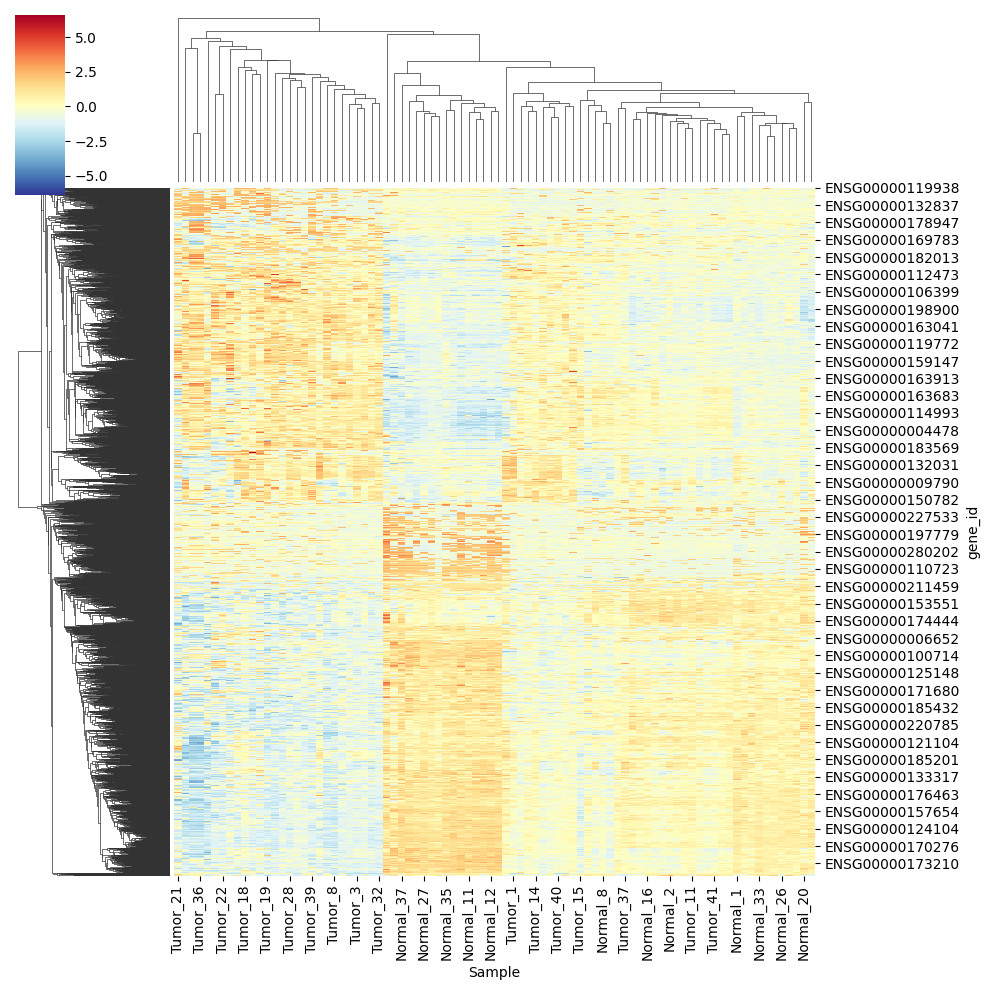

In [ ]:
sns.clustermap(grapher, z_score=0, cmap = 'RdYlBu_r')

In [ ]:
senGPT = ['CDKN2A',
 'CDKN1A',
 'CDKN2B',
 'IL6',
 'IL8',
 'CXCL1',
 'CXCL2',
 'CXCL3',
 'CXCL5',
 'CXCL6',
 'MMP1',
 'MMP2',
 'MMP3',
 'MMP9',
 'MMP10',
 'MMP12',
 'MMP13',
 'MMP14',
 'SERPINE1',
 'IGFBP7',
 'SASP',
 'CCND1',
 'CCNE1',
 'BCL2',
 'BAX',
 'IL1A',
 'IL1B',
 'IL10',
 'TNF',
 'TGFB1',
 'CCL2',
 'CCL5',
 'CCL20',
 'ICAM1',
 'VCAM1',
 'RELA',
 'STAT1',
 'STAT3',
 'HIF1A',
 'PTGS2',
 'NOX4',
 'EDN1',
 'COL1A1',
 'COL1A2',
 'COL3A1',
 'TIMP1',
 'TIMP2',
 'SOD2',
 'NRF2',
 'LMNB1',
 'GDF15',
 'BMP2',
 'BMP4',
 'BMP6',
 'CTGF',
 'FGF2',
 'FGF7',
 'IGFBP2',
 'IGFBP3',
 'IGFBP4',
 'IGFBP5',
 'IGFBP6',
 'LOX',
 'LOXL2',
 'MMP11',
 'MMP15',
 'MMP16',
 'MMP17',
 'MMP19',
 'MMP20',
 'MMP24',
 'MMP25',
 'MMP27',
 'MMP28',
 'ANXA1',
 'TP53',
 'CDKN1B',
 'ATM',
 'ATR',
 'CHEK1',
 'CHEK2',
 'SIRT1',
 'SIRT6',
 'TERT',
 'LMNA',
 'RB1',
 'E2F1',
 'E2F2',
 'E2F3',
 'CCND2',
 'CCND3',
 'FOXO1',
 'FOXO3',
 'FOXO4',
 'HSPB1',
 'PML',
 'SAHF',
 'DDIT3',
 'XBP1',
 'ATF6']

In [ ]:
sigs[sigs.Symbol.isin(senGPT)].index
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000059588,20.821002,-0.703796,0.127238,-5.531350,3.177754e-08,2.579932e-07,TARBP1
ENSG00000049245,92.363626,0.652114,0.077931,8.367861,5.867364e-17,3.356222e-15,VAMP3
ENSG00000094963,22.745247,1.703675,0.256408,6.644384,3.044883e-11,5.095353e-10,FMO2
ENSG00000116128,11.511589,-1.149214,0.155788,-7.376757,1.621918e-13,4.357166e-12,BCL9
ENSG00000116741,122.876750,0.859270,0.200409,4.287581,1.806294e-05,7.620270e-05,RGS2
...,...,...,...,...,...,...,...
ENSG00000279245,9.220747,-1.100489,0.490418,-2.243982,2.483354e-02,4.500612e-02,FAM223A
ENSG00000281852,21.951429,-1.340155,0.488772,-2.741881,6.108853e-03,1.320805e-02,LINC00891
ENSG00000260081,10.243679,-1.204547,0.505824,-2.381359,1.724889e-02,3.276832e-02,MRFAP1P1


In [ ]:
dds_sub = dds[:, sigs[sigs.Symbol.isin(senGPT)].index]
dds_sub

View of AnnData object with n_obs × n_vars = 86 × 43
    obs: 'Condition'
    uns: 'mean_disp', 'disp_function_type', '_squared_logres', 'prior_disp_var', 'pca', 'Condition_colors'
    obsm: 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable', 'X_pca'
    varm: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier', 'PCs'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks', 'log1p'

In [ ]:
grapher = pd.DataFrame(dds_sub.layers['log1p'].T,
                       index=dds_sub.var_names, columns=dds_sub.obs_names)
grapher.index = grapher.index.map(mapper.mapper)
grapher

Sample,Normal_1,Normal_2,Normal_3,Normal_4,Normal_5,Normal_6,Normal_7,Normal_8,Normal_9,Normal_10,...,Tumor_34,Tumor_35,Tumor_36,Tumor_37,Tumor_38,Tumor_39,Tumor_40,Tumor_41,Tumor_42,Tumor_43
gene_id,,,,,,,,,,,,,,,,,,,,,
E2F2,4.280884,0.670295,0.741818,4.419241,4.204575,4.313257,4.221835,4.066526,0.718680,4.226858,...,0.583526,2.000200,1.487585,4.341465,1.227330,1.258995,0.708316,4.264618,1.791300,1.499262
ATF6,2.528486,2.664961,2.388557,2.472947,2.550966,2.268886,2.710255,2.687606,2.685969,2.478166,...,3.035369,3.048540,2.849282,2.665838,3.086712,3.200205,2.736182,2.593555,2.772071,2.958108
LMNA,6.557638,6.857556,6.877172,6.531197,6.852833,6.869154,6.773149,5.494115,5.802847,6.170604,...,5.628776,5.589406,5.491253,7.312927,5.904916,5.947107,5.635804,6.337173,5.655442,5.695522
CCND1,4.390652,3.997642,3.781692,3.967911,3.897171,3.741851,3.763508,4.190536,3.632583,3.706397,...,4.605603,4.375911,5.039101,4.355875,5.640518,6.387692,5.066871,3.880452,4.753043,4.206024
CHEK1,0.717153,1.068025,0.741818,0.791349,0.685597,0.734087,0.694329,0.618439,0.718680,0.689476,...,0.583526,2.116673,2.628212,0.749055,1.227330,1.258995,1.118787,0.708744,2.036402,2.177742
IGFBP6,5.927852,5.749963,6.183922,6.597511,6.458757,5.990857,6.367109,4.862941,5.220635,5.163171,...,2.424847,2.623296,1.814758,5.391534,3.191177,1.929257,3.980784,5.184069,2.538466,1.827379
MMP19,3.709822,4.128876,3.424043,3.315646,4.528300,3.296055,4.627312,2.943206,3.449987,2.988746,...,1.216999,2.623296,1.945366,4.596331,2.629337,2.147760,3.494920,3.719070,2.470415,1.283371
CCND2,3.479940,3.174528,3.034737,2.814380,3.030092,2.713802,3.403481,3.251336,2.755197,2.883427,...,1.749909,2.315436,1.272508,3.282601,2.438205,2.326975,3.024359,2.801635,1.921342,2.509984
FOXO1,2.989446,3.287654,2.572403,3.513693,3.204329,2.375111,3.334483,2.495547,2.819941,2.988746,...,0.583526,2.116673,0.618746,2.665838,2.108554,1.649262,2.425306,2.593555,1.641783,1.676718


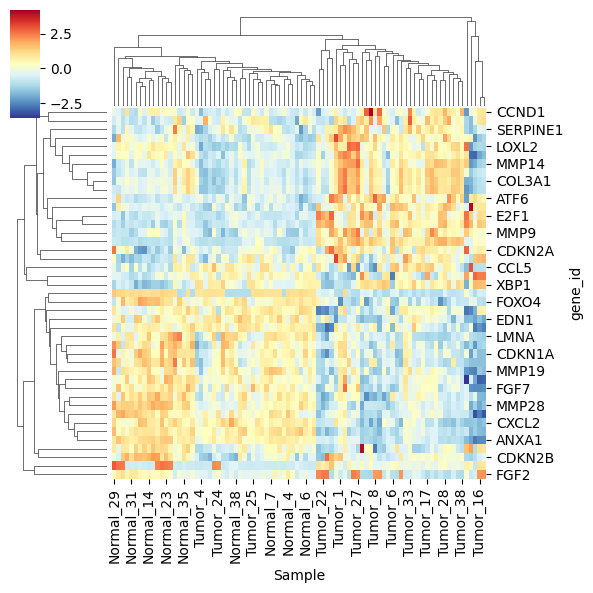

In [ ]:
ax1 = sns.clustermap(grapher, z_score=0, cmap = 'RdYlBu_r', figsize=(6,6))

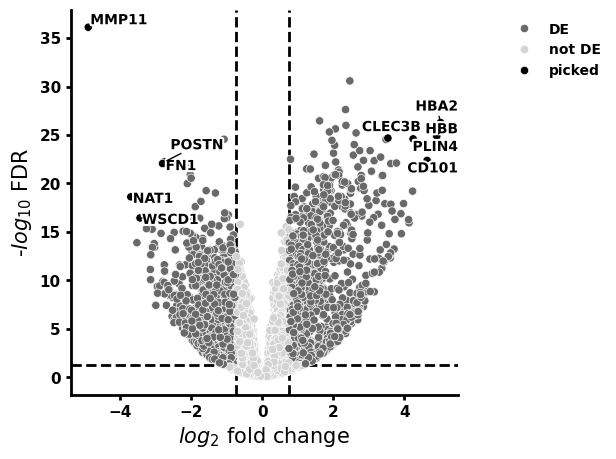

In [ ]:
#volcano
from sanbomics.plots import volcano

volcano(res, symbol='Symbol')

In [ ]:
grapher.index

Index(['E2F2', 'ATF6', 'LMNA', 'CCND1', 'CHEK1', 'IGFBP6', 'MMP19', 'CCND2',
       'FOXO1', 'BMP4', 'MMP14', 'HIF1A', 'FGF7', 'PML', 'COL1A1', 'IGFBP4',
       'CCL5', 'MMP28', 'CCL2', 'GDF15', 'IGFBP2', 'IGFBP5', 'COL3A1', 'STAT1',
       'E2F1', 'MMP9', 'MMP11', 'XBP1', 'FGF2', 'CXCL2', 'LOX', 'LMNB1',
       'EDN1', 'CDKN1A', 'SERPINE1', 'COL1A2', 'IL6', 'LOXL2', 'CDKN2B',
       'ANXA1', 'CDKN2A', 'FOXO4', 'TIMP1'],
      dtype='object', name='gene_id')

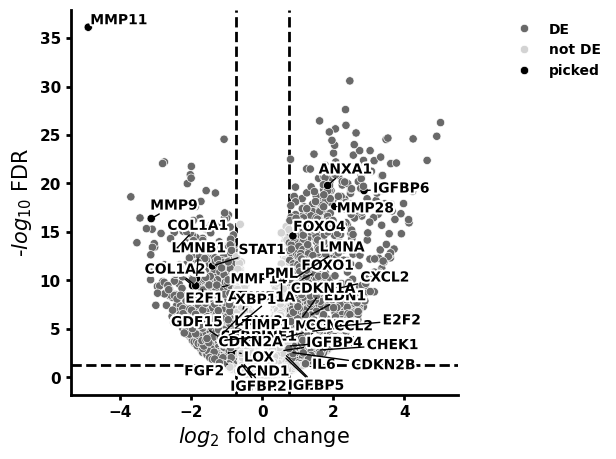

In [ ]:
volcano(res, symbol='Symbol', to_label = grapher.index)

In [ ]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000001461,8.317240,-0.046359,0.120494,-0.384740,7.004301e-01,7.629069e-01,NIPAL3
ENSG00000059588,20.821002,-0.703796,0.127238,-5.531350,3.177754e-08,2.579932e-07,TARBP1
ENSG00000049245,92.363626,0.652114,0.077931,8.367861,5.867364e-17,3.356222e-15,VAMP3
ENSG00000058799,39.074639,-0.454633,0.106325,-4.275897,1.903694e-05,7.966391e-05,YIPF1
ENSG00000081870,29.132877,-0.270078,0.103586,-2.607285,9.126327e-03,1.874423e-02,HSPB11
...,...,...,...,...,...,...,...
ENSG00000223546,25.870591,1.214182,0.530429,2.289058,2.207599e-02,4.055577e-02,LINC00630
ENSG00000267064,43.701039,0.955599,0.449748,2.124741,3.360819e-02,5.851871e-02,UXT-AS1
ENSG00000235437,18.248603,-0.050536,0.131797,-0.383437,7.013957e-01,7.637375e-01,LINC01278


In [ ]:
# Apply the filtering conditions
res['-log10(FDR)'] = -np.log10(res['padj'])
filtered_res = res[( (res['log2FoldChange'] > 1) | (res['log2FoldChange'] < -1)) &
                   (res['-log10(FDR)'] > 2) & (res['-log10(FDR)'] < 15)]

# View the filtered results
print(filtered_res)

                   baseMean  log2FoldChange     lfcSE      stat        pvalue  \
gene_id                                                                         
ENSG00000094963   22.745247        1.703675  0.256408  6.644384  3.044883e-11   
ENSG00000116128   11.511589       -1.149214  0.155788 -7.376757  1.621918e-13   
ENSG00000282608    9.218055       -1.013005  0.185839 -5.450974  5.009466e-08   
ENSG00000130695    8.315431       -1.061245  0.166329 -6.380401  1.766254e-10   
ENSG00000133048  157.746768       -1.094643  0.370252 -2.956481  3.111714e-03   
...                     ...             ...       ...       ...           ...   
ENSG00000078596   69.452618        1.766948  0.249460  7.083081  1.409845e-12   
ENSG00000223749   14.737999       -1.228123  0.260515 -4.714216  2.426432e-06   
ENSG00000130052   10.953461        1.057671  0.146515  7.218876  5.241901e-13   
ENSG00000189221   33.792350        1.721748  0.314720  5.470723  4.482031e-08   
ENSG00000065923   12.675659 

In [ ]:
filtered_res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,-log10(FDR)
gene_id,,,,,,,,
ENSG00000094963,22.745247,1.703675,0.256408,6.644384,3.044883e-11,5.095353e-10,FMO2,9.292826
ENSG00000116128,11.511589,-1.149214,0.155788,-7.376757,1.621918e-13,4.357166e-12,BCL9,11.360796
ENSG00000282608,9.218055,-1.013005,0.185839,-5.450974,5.009466e-08,3.884660e-07,ADORA3,6.410647
ENSG00000130695,8.315431,-1.061245,0.166329,-6.380401,1.766254e-10,2.460326e-09,CEP85,8.609007
ENSG00000133048,157.746768,-1.094643,0.370252,-2.956481,3.111714e-03,7.309903e-03,CHI3L1,2.136088
...,...,...,...,...,...,...,...,...
ENSG00000078596,69.452618,1.766948,0.249460,7.083081,1.409845e-12,3.170360e-11,ITM2A,10.498891
ENSG00000223749,14.737999,-1.228123,0.260515,-4.714216,2.426432e-06,1.269678e-05,MIR503HG,4.896306
ENSG00000130052,10.953461,1.057671,0.146515,7.218876,5.241901e-13,1.278106e-11,STARD8,10.893433


In [ ]:
#logfdr > 2 and less than 15
#logfc > 1 and <-1

In [ ]:
gene_selection = filtered_res.index.to_list()
gene_selection

['ENSG00000094963',
 'ENSG00000116128',
 'ENSG00000282608',
 'ENSG00000130695',
 'ENSG00000133048',
 'ENSG00000134201',
 'ENSG00000123080',
 'ENSG00000085831',
 'ENSG00000120949',
 'ENSG00000143578',
 'ENSG00000117586',
 'ENSG00000158315',
 'ENSG00000162552',
 'ENSG00000162676',
 'ENSG00000162745',
 'ENSG00000162817',
 'ENSG00000170989',
 'ENSG00000157193',
 'ENSG00000175147',
 'ENSG00000092853',
 'ENSG00000185436',
 'ENSG00000184005',
 'ENSG00000175130',
 'ENSG00000184371',
 'ENSG00000183682',
 'ENSG00000117525',
 'ENSG00000186160',
 'ENSG00000160781',
 'ENSG00000162913',
 'ENSG00000169962',
 'ENSG00000187513',
 'ENSG00000188783',
 'ENSG00000188672',
 'ENSG00000122176',
 'ENSG00000143365',
 'ENSG00000142627',
 'ENSG00000179456',
 'ENSG00000186197',
 'ENSG00000134242',
 'ENSG00000123473',
 'ENSG00000132698',
 'ENSG00000183856',
 'ENSG00000162482',
 'ENSG00000007968',
 'ENSG00000126709',
 'ENSG00000054277',
 'ENSG00000117009',
 'ENSG00000244457',
 'ENSG00000135750',
 'ENSG00000143674',


In [ ]:
# Print first few rows of the data
print(data.head())

# Print gene selection list
print(gene_selection)


           gene_id  Normal_1  Normal_2  Normal_3  Normal_4  Normal_5  \
0  ENSG00000001461         6         8        12         7         9   
1  ENSG00000059588        14        18        17        10        16   
2  ENSG00000049245       115       109        86       107       106   
3  ENSG00000058799        26        31        28        21        27   
4  ENSG00000081870        21        26        23        17        24   

   Normal_6  Normal_7  Normal_8  Normal_9  ...  Tumor_34  Tumor_35  Tumor_36  \
0         9         7        11         8  ...        16         8         8   
1        12        16        26        16  ...        41        25        39   
2        88       101        89        81  ...        56        87        53   
3        35        34        59        52  ...        80        26        81   
4        23        23        33        28  ...        51        23        45   

   Tumor_37  Tumor_38  Tumor_39  Tumor_40  Tumor_41  Tumor_42  Tumor_43  
0         7 

In [ ]:
import pandas as pd

# Assuming 'preprocessed_data' is the DataFrame with your gene expression data
# Example: preprocessed_data = pd.read_csv('preprocessed_data.csv', index_col=0)

# Filter the dataset to include only the genes in the gene_selection list
filtered_data = data[data['gene_id'].isin(gene_selection)]

# View the filtered data
filtered_data


,gene_id,Normal_1,Normal_2,Normal_3,Normal_4,Normal_5,Normal_6,Normal_7,Normal_8,Normal_9,...,Tumor_34,Tumor_35,Tumor_36,Tumor_37,Tumor_38,Tumor_39,Tumor_40,Tumor_41,Tumor_42,Tumor_43
7,ENSG00000094963,17,39,19,53,80,20,29,34,23,...,1,5,5,5,6,2,11,22,2,2
9,ENSG00000116128,7,7,5,6,7,6,7,9,9,...,24,8,14,15,30,23,13,10,16,28
27,ENSG00000282608,2,3,3,3,3,3,6,6,16,...,12,20,24,1,14,28,16,10,9,6
34,ENSG00000130695,4,5,3,4,4,6,4,8,7,...,13,11,24,7,18,12,7,5,20,22
38,ENSG00000133048,45,30,88,26,59,79,279,51,303,...,31,34,27,25,143,348,50,205,134,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14878,ENSG00000078596,150,172,132,79,102,106,137,203,100,...,11,15,5,78,21,15,26,95,7,36
14899,ENSG00000223749,15,12,6,4,7,5,14,40,21,...,2,18,3,57,15,5,15,9,25,2
14936,ENSG00000130052,12,10,6,13,20,8,11,10,11,...,4,8,2,12,9,7,10,9,4,4
14946,ENSG00000189221,34,16,8,85,47,14,21,21,21,...,26,5,43,15,3,38,13,30,69,1


In [ ]:
filtered_data.to_csv('filtered_data.csv')

In [ ]:
target_data = filtered_data.set_index('gene_id')
target_data

,Normal_1,Normal_2,Normal_3,Normal_4,Normal_5,Normal_6,Normal_7,Normal_8,Normal_9,Normal_10,...,Tumor_34,Tumor_35,Tumor_36,Tumor_37,Tumor_38,Tumor_39,Tumor_40,Tumor_41,Tumor_42,Tumor_43
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000094963,17,39,19,53,80,20,29,34,23,57,...,1,5,5,5,6,2,11,22,2,2
ENSG00000116128,7,7,5,6,7,6,7,9,9,6,...,24,8,14,15,30,23,13,10,16,28
ENSG00000282608,2,3,3,3,3,3,6,6,16,7,...,12,20,24,1,14,28,16,10,9,6
ENSG00000130695,4,5,3,4,4,6,4,8,7,4,...,13,11,24,7,18,12,7,5,20,22
ENSG00000133048,45,30,88,26,59,79,279,51,303,120,...,31,34,27,25,143,348,50,205,134,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000078596,150,172,132,79,102,106,137,203,100,99,...,11,15,5,78,21,15,26,95,7,36
ENSG00000223749,15,12,6,4,7,5,14,40,21,7,...,2,18,3,57,15,5,15,9,25,2
ENSG00000130052,12,10,6,13,20,8,11,10,11,9,...,4,8,2,12,9,7,10,9,4,4


In [ ]:
# Calculate Pearson correlation matrix for the selected target genes
correlation_matrix = target_data.corr(method='pearson')

# View the correlation matrix (this will be a square matrix with correlations between each pair of genes)
print(correlation_matrix.head())


          Normal_1  Normal_2  Normal_3  Normal_4  Normal_5  Normal_6  \
Normal_1  1.000000  0.501228  0.463982  0.651249  0.710205  0.551439   
Normal_2  0.501228  1.000000  0.909550  0.662122  0.786934  0.854202   
Normal_3  0.463982  0.909550  1.000000  0.634516  0.775579  0.851789   
Normal_4  0.651249  0.662122  0.634516  1.000000  0.840079  0.819135   
Normal_5  0.710205  0.786934  0.775579  0.840079  1.000000  0.792458   

          Normal_7  Normal_8  Normal_9  Normal_10  ...  Tumor_34  Tumor_35  \
Normal_1  0.680308  0.612800  0.480978   0.490860  ...  0.173905  0.658528   
Normal_2  0.757278  0.643334  0.707837   0.849336  ...  0.262663  0.320644   
Normal_3  0.741602  0.590916  0.745532   0.859521  ...  0.366271  0.266983   
Normal_4  0.679964  0.557545  0.484546   0.597143  ...  0.158313  0.302067   
Normal_5  0.883886  0.743043  0.740364   0.806949  ...  0.265859  0.394456   

          Tumor_36  Tumor_37  Tumor_38  Tumor_39  Tumor_40  Tumor_41  \
Normal_1  0.103678  0.7924

In [ ]:
# Set a correlation threshold (e.g., 0.3)
threshold = 0.3

# Create a mask to filter correlations above the threshold
significant_correlations = correlation_matrix[(correlation_matrix.abs() > threshold) & (correlation_matrix != 1)]

# Display significant correlations
print(significant_correlations)


          Normal_1  Normal_2  Normal_3  Normal_4  Normal_5  Normal_6  \
Normal_1       NaN  0.501228  0.463982  0.651249  0.710205  0.551439   
Normal_2  0.501228       NaN  0.909550  0.662122  0.786934  0.854202   
Normal_3  0.463982  0.909550       NaN  0.634516  0.775579  0.851789   
Normal_4  0.651249  0.662122  0.634516       NaN  0.840079  0.819135   
Normal_5  0.710205  0.786934  0.775579  0.840079       NaN  0.792458   
...            ...       ...       ...       ...       ...       ...   
Tumor_39  0.523514       NaN       NaN       NaN       NaN       NaN   
Tumor_40  0.793659  0.406878  0.330923  0.407436  0.455946  0.376033   
Tumor_41  0.468755  0.841367  0.855124  0.559875  0.802707  0.758806   
Tumor_42  0.491691       NaN       NaN       NaN       NaN       NaN   
Tumor_43       NaN       NaN  0.386135       NaN  0.343485  0.320054   

          Normal_7  Normal_8  Normal_9  Normal_10  ...  Tumor_34  Tumor_35  \
Normal_1  0.680308  0.612800  0.480978   0.490860  ...   

In [ ]:
# Fill NaN values with 0 or any other value you choose
correlation_matrix_filled = correlation_matrix.fillna(0)

# Alternatively, fill NaNs with column-wise means
# correlation_matrix_filled = correlation_matrix.apply(lambda x: x.fillna(x.mean()), axis=0)

# Now, filter the significant correlations
significant_correlations = correlation_matrix_filled[(correlation_matrix_filled.abs() > threshold) & (correlation_matrix_filled != 1)]

# Display the filtered significant correlations
print(significant_correlations)


          Normal_1  Normal_2  Normal_3  Normal_4  Normal_5  Normal_6  \
Normal_1       NaN  0.501228  0.463982  0.651249  0.710205  0.551439   
Normal_2  0.501228       NaN  0.909550  0.662122  0.786934  0.854202   
Normal_3  0.463982  0.909550       NaN  0.634516  0.775579  0.851789   
Normal_4  0.651249  0.662122  0.634516       NaN  0.840079  0.819135   
Normal_5  0.710205  0.786934  0.775579  0.840079       NaN  0.792458   
...            ...       ...       ...       ...       ...       ...   
Tumor_39  0.523514       NaN       NaN       NaN       NaN       NaN   
Tumor_40  0.793659  0.406878  0.330923  0.407436  0.455946  0.376033   
Tumor_41  0.468755  0.841367  0.855124  0.559875  0.802707  0.758806   
Tumor_42  0.491691       NaN       NaN       NaN       NaN       NaN   
Tumor_43       NaN       NaN  0.386135       NaN  0.343485  0.320054   

          Normal_7  Normal_8  Normal_9  Normal_10  ...  Tumor_34  Tumor_35  \
Normal_1  0.680308  0.612800  0.480978   0.490860  ...   

In [ ]:
# Drop rows/columns with NaN values from the correlation matrix
correlation_matrix_dropped = correlation_matrix.dropna(axis=0, how='any').dropna(axis=1, how='any')

# Now filter the significant correlations
significant_correlations = correlation_matrix_dropped[(correlation_matrix_dropped.abs() > threshold) & (correlation_matrix_dropped != 1)]

# Display the filtered significant correlations
print(significant_correlations)


          Normal_1  Normal_2  Normal_3  Normal_4  Normal_5  Normal_6  \
Normal_1       NaN  0.501228  0.463982  0.651249  0.710205  0.551439   
Normal_2  0.501228       NaN  0.909550  0.662122  0.786934  0.854202   
Normal_3  0.463982  0.909550       NaN  0.634516  0.775579  0.851789   
Normal_4  0.651249  0.662122  0.634516       NaN  0.840079  0.819135   
Normal_5  0.710205  0.786934  0.775579  0.840079       NaN  0.792458   
...            ...       ...       ...       ...       ...       ...   
Tumor_39  0.523514       NaN       NaN       NaN       NaN       NaN   
Tumor_40  0.793659  0.406878  0.330923  0.407436  0.455946  0.376033   
Tumor_41  0.468755  0.841367  0.855124  0.559875  0.802707  0.758806   
Tumor_42  0.491691       NaN       NaN       NaN       NaN       NaN   
Tumor_43       NaN       NaN  0.386135       NaN  0.343485  0.320054   

          Normal_7  Normal_8  Normal_9  Normal_10  ...  Tumor_34  Tumor_35  \
Normal_1  0.680308  0.612800  0.480978   0.490860  ...   

In [ ]:
import networkx as nx

# Create an empty undirected graph
grn = nx.Graph()

# Add edges to the graph where significant correlations exist
for gene1 in significant_correlations.columns:
    for gene2 in significant_correlations.index:
        if gene1 != gene2 and abs(significant_correlations.loc[gene2, gene1]) > threshold:
            grn.add_edge(gene1, gene2, weight=significant_correlations.loc[gene2, gene1])

# Check the number of edges in the GRN
print(f"Number of edges in the GRN: {grn.number_of_edges()}")


Number of edges in the GRN: 2116


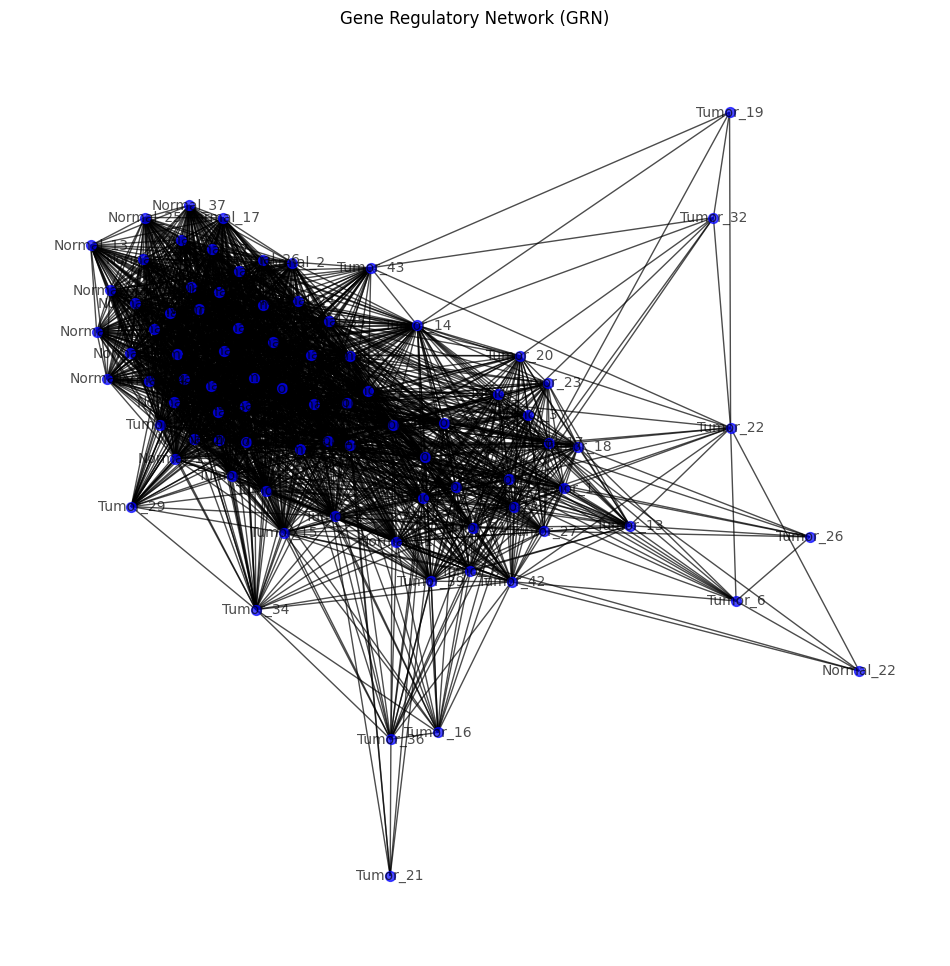

In [ ]:
import matplotlib.pyplot as plt

# Set up the visualization
plt.figure(figsize=(12, 12))

# Draw the network (you can customize the layout and appearance)
nx.draw_networkx(grn, node_size=50, node_color='blue', with_labels=True, font_size=10, alpha=0.7)

# Set plot title
plt.title("Gene Regulatory Network (GRN)")
plt.axis("off")  # Hide axes for better visualization
plt.show()


In [ ]:
# Calculate degree centrality
degree_centrality = nx.degree_centrality(grn)

# Sort genes by degree centrality
sorted_genes_by_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)

# Display the top 10 genes by degree centrality
print("Top 10 genes by degree centrality:")
for gene, centrality in sorted_genes_by_degree[:10]:
    print(f"{gene}: {centrality}")


Top 10 genes by degree centrality:
Tumor_5: 0.9294117647058824
Normal_8: 0.9058823529411765
Tumor_12: 0.8941176470588235
Tumor_33: 0.8941176470588235
Tumor_37: 0.8705882352941177
Normal_1: 0.8588235294117647
Normal_21: 0.8588235294117647
Normal_40: 0.8588235294117647
Normal_35: 0.8352941176470589
Tumor_11: 0.8352941176470589


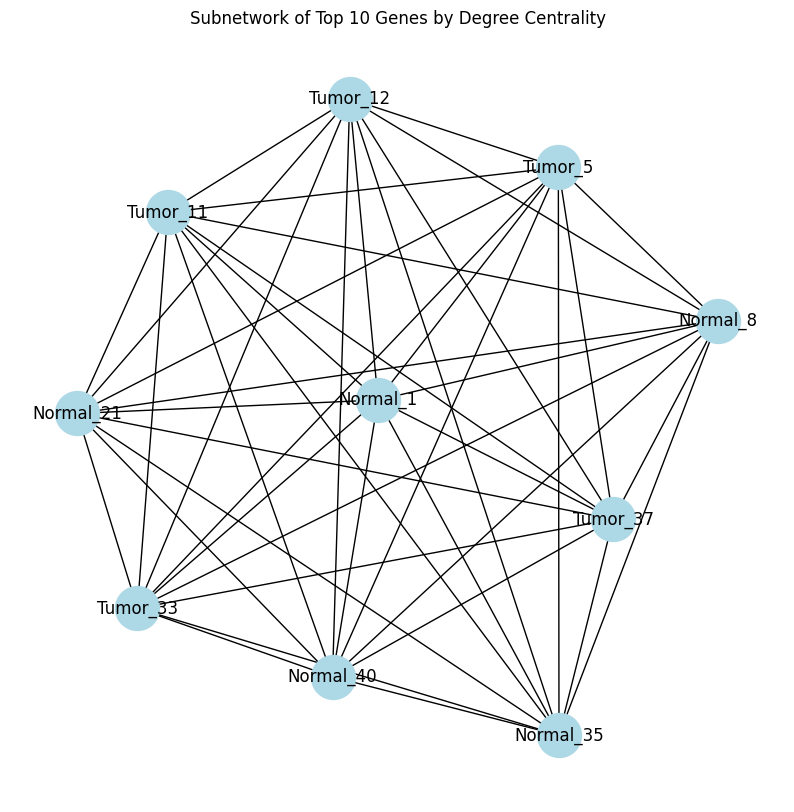

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Assuming 'grn' is your Gene Regulatory Network (created using NetworkX)
top_genes = ['Tumor_5', 'Normal_8', 'Tumor_12', 'Tumor_33', 'Tumor_37',
             'Normal_1', 'Normal_21', 'Normal_40', 'Normal_35', 'Tumor_11']

# Subset the GRN to include only the top 10 genes by degree centrality
sub_grn = grn.subgraph(top_genes)

# Visualize the subgraph (network of top 10 genes)
plt.figure(figsize=(10, 10))
nx.draw_networkx(sub_grn, node_size=1000, node_color='lightblue', with_labels=True, font_size=12)
plt.title("Subnetwork of Top 10 Genes by Degree Centrality")
plt.axis("off")
plt.show()


In [ ]:
# Calculate degree centrality for each node in the network
degree_centrality = nx.degree_centrality(grn)

# Sort the genes by their degree centrality in descending order
sorted_degree_centrality = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)

# Display the top 10 genes by degree centrality
print("Top 10 genes by degree centrality:")
for gene, centrality in sorted_degree_centrality[:10]:
    print(f"{gene}: {centrality}")


Top 10 genes by degree centrality:
Tumor_5: 0.9294117647058824
Normal_8: 0.9058823529411765
Tumor_12: 0.8941176470588235
Tumor_33: 0.8941176470588235
Tumor_37: 0.8705882352941177
Normal_1: 0.8588235294117647
Normal_21: 0.8588235294117647
Normal_40: 0.8588235294117647
Normal_35: 0.8352941176470589
Tumor_11: 0.8352941176470589


In [ ]:
# Calculate betweenness centrality for each node
betweenness_centrality = nx.betweenness_centrality(grn)

# Sort the genes by their betweenness centrality in descending order
sorted_betweenness_centrality = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)

# Display the top 10 genes by betweenness centrality
print("Top 10 genes by betweenness centrality:")
for gene, centrality in sorted_betweenness_centrality[:10]:
    print(f"{gene}: {centrality}")


Top 10 genes by betweenness centrality:
Tumor_5: 0.03819053821462784
Tumor_14: 0.03090833956024389
Tumor_33: 0.022148497672213215
Tumor_35: 0.0210773229377773
Normal_41: 0.020605672329979712
Normal_8: 0.01903507364690873
Tumor_40: 0.018811807777550482
Tumor_12: 0.018482442943744907
Tumor_37: 0.017793266617773074
Normal_21: 0.016729755494487995


In [ ]:
# Calculate closeness centrality for each node
closeness_centrality = nx.closeness_centrality(grn)

# Sort the genes by their closeness centrality in descending order
sorted_closeness_centrality = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)

# Display the top 10 genes by closeness centrality
print("Top 10 genes by closeness centrality:")
for gene, centrality in sorted_closeness_centrality[:10]:
    print(f"{gene}: {centrality}")


Top 10 genes by closeness centrality:
Tumor_5: 0.9340659340659341
Normal_8: 0.9139784946236559
Tumor_12: 0.9042553191489362
Tumor_33: 0.9042553191489362
Tumor_37: 0.8854166666666666
Normal_1: 0.8762886597938144
Normal_21: 0.8762886597938144
Normal_40: 0.8762886597938144
Normal_35: 0.8585858585858586
Tumor_11: 0.8585858585858586


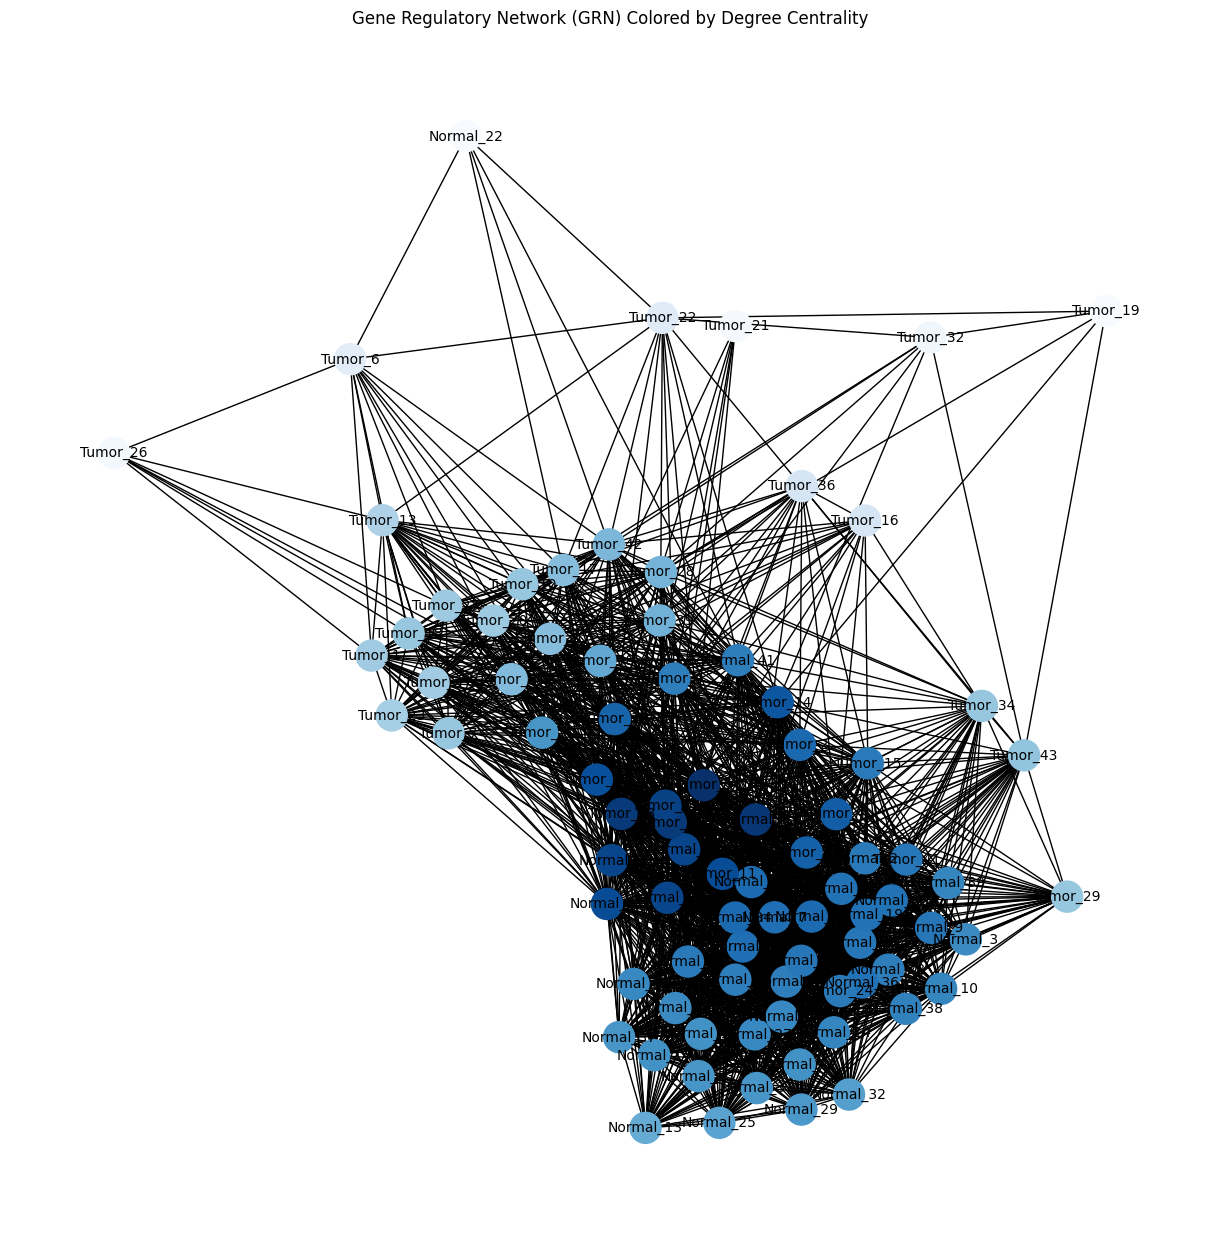

In [ ]:
import matplotlib.pyplot as plt

# Create a plot for the network, colored by degree centrality
plt.figure(figsize=(12, 12))
node_color = [degree_centrality[node] for node in grn.nodes()]
nx.draw(grn, node_size=500, node_color=node_color, cmap='Blues', with_labels=True, font_size=10)
plt.title("Gene Regulatory Network (GRN) Colored by Degree Centrality")
plt.show()

# Alternatively, you can visualize the network using betweenness centrality or closeness centrality:
# node_color = [betweenness_centrality[node] for node in grn.nodes()]
# nx.draw(grn, node_size=500, node_color=node_color, cmap='Reds', with_labels=True, font_size=10)


In [ ]:
import pandas as pd
import networkx as nx

# Assuming you have already constructed the GRN (Gene Regulatory Network) as 'grn'

# Calculate degree, betweenness, and closeness centrality
degree_centrality = nx.degree_centrality(grn)
betweenness_centrality = nx.betweenness_centrality(grn)
closeness_centrality = nx.closeness_centrality(grn)

# Sort the centrality measures in descending order to find top genes
top_degree_genes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_betweenness_genes = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_closeness_genes = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

# Display the top 10 genes for each centrality measure
print("Top 10 Genes by Degree Centrality:")
for gene, centrality in top_degree_genes:
    print(f"{gene}: {centrality}")

print("\nTop 10 Genes by Betweenness Centrality:")
for gene, centrality in top_betweenness_genes:
    print(f"{gene}: {centrality}")

print("\nTop 10 Genes by Closeness Centrality:")
for gene, centrality in top_closeness_genes:
    print(f"{gene}: {centrality}")

# 2. **Conclusion & Interpretation**
# - **Degree Centrality**: These genes are highly connected in the network and might serve as **key regulatory hubs**. High degree centrality genes are good candidates for further investigation as **drug targets**.
# - **Betweenness Centrality**: Genes with high betweenness centrality are **critical intermediaries** in the network. These genes link various parts of the network and play important roles in regulating multiple biological processes.
# - **Closeness Centrality**: Genes with high closeness centrality are **master regulators** that can efficiently regulate many other genes. They may be involved in fast and widespread biological responses, making them **key players** in disease regulation.

# 3. **Summary Output**
print("\nConclusion:")
print("By performing centrality analysis, we identified genes with the highest degree, betweenness, and closeness centrality.")
print("These genes are crucial in controlling the network's behavior:")
print("- **High degree centrality genes** are highly connected and can be considered **key regulatory hubs**.")
print("- **High betweenness centrality genes** act as **critical intermediaries** controlling information flow in the network.")
print("- **High closeness centrality genes** are **master regulators** and are involved in fast regulatory responses.")
print("\nThese results help in identifying **potential drug targets** and **biomarkers** for further investigation.")



Top 10 Genes by Degree Centrality:
Tumor_5: 0.9294117647058824
Normal_8: 0.9058823529411765
Tumor_12: 0.8941176470588235
Tumor_33: 0.8941176470588235
Tumor_37: 0.8705882352941177
Normal_1: 0.8588235294117647
Normal_21: 0.8588235294117647
Normal_40: 0.8588235294117647
Normal_35: 0.8352941176470589
Tumor_11: 0.8352941176470589

Top 10 Genes by Betweenness Centrality:
Tumor_5: 0.03819053821462784
Tumor_14: 0.03090833956024389
Tumor_33: 0.022148497672213215
Tumor_35: 0.0210773229377773
Normal_41: 0.020605672329979712
Normal_8: 0.01903507364690873
Tumor_40: 0.018811807777550482
Tumor_12: 0.018482442943744907
Tumor_37: 0.017793266617773074
Normal_21: 0.016729755494487995

Top 10 Genes by Closeness Centrality:
Tumor_5: 0.9340659340659341
Normal_8: 0.9139784946236559
Tumor_12: 0.9042553191489362
Tumor_33: 0.9042553191489362
Tumor_37: 0.8854166666666666
Normal_1: 0.8762886597938144
Normal_21: 0.8762886597938144
Normal_40: 0.8762886597938144
Normal_35: 0.8585858585858586
Tumor_11: 0.858585858585